In [1]:
# Install dependencies
!pip install geopandas gdown --quiet

In [2]:
# Import libraries
import geopandas as gpd
import gdown

# Download GeoPackage from Google Drive
url = "https://drive.google.com/uc?id=1__HTvAVT-pwWywqSS0lQywSjuyJM18WW"
output = "nil_metrics_2024.gpkg"
gdown.download(url, output, quiet=False)

# Load NIL metrics layer
nil_gdf = gpd.read_file(output, layer="accessibility_metrics")

# Preview key indicators
nil_gdf.head()

Downloading...
From: https://drive.google.com/uc?id=1__HTvAVT-pwWywqSS0lQywSjuyJM18WW
To: /content/nil_metrics_2024.gpkg
100%|██████████| 553k/553k [00:00<00:00, 67.7MB/s]


,ID_NIL,NIL,Valido_dal,Valido_al,Fonte,Shape_Length,Shape_Area,OBJECTID,GAI_m2,sqrt_pop,GER,num_cells_total,num_cells_valid,perc_valid_cells,valid_nil,geometry
0,48,RONCHETTO SUL NAVIGLIO - Q.RE LODOVICO IL MORO,05/02/2020,Vigente,Milano 2030 - PGT Approvato,8723.368714,2.406306e+06,89,399.082522,19.676409,23.972256,41,34,0.829268,True,"POLYGON ((9.15422 45.43775, 9.15274 45.43887, ..."
1,64,TRENNO,05/02/2020,Vigente,Milano 2030 - PGT Approvato,3309.998800,4.896921e+05,90,671.820872,21.990972,31.122568,8,8,1.000000,False,"POLYGON ((9.10623 45.49016, 9.10591 45.49084, ..."
2,67,PORTELLO,05/02/2020,Vigente,Milano 2030 - PGT Approvato,3800.750663,9.096022e+05,91,537.169905,24.910486,26.583914,12,11,0.916667,True,"POLYGON ((9.15636 45.48785, 9.15495 45.48852, ..."
3,81,BOVISASCA,05/02/2020,Vigente,Milano 2030 - PGT Approvato,7105.469715,1.578028e+06,92,478.945907,17.427361,33.463710,29,23,0.793103,True,"POLYGON ((9.16803 45.52234, 9.16763 45.52272, ..."
4,84,PARCO NORD,05/02/2020,Vigente,Milano 2030 - PGT Approvato,11741.717005,1.532331e+06,93,830.509314,12.310862,77.485889,26,6,0.230769,False,"POLYGON ((9.2004 45.52848, 9.20028 45.52846, 9..."


In [3]:
# Filter only rows where valid_nil is True
nil_gdf_valid = nil_gdf[nil_gdf["valid_nil"] == True].copy()

# Quick check
nil_gdf_valid.head()


,ID_NIL,NIL,Valido_dal,Valido_al,Fonte,Shape_Length,Shape_Area,OBJECTID,GAI_m2,sqrt_pop,GER,num_cells_total,num_cells_valid,perc_valid_cells,valid_nil,geometry
0,48,RONCHETTO SUL NAVIGLIO - Q.RE LODOVICO IL MORO,05/02/2020,Vigente,Milano 2030 - PGT Approvato,8723.368714,2.406306e+06,89,399.082522,19.676409,23.972256,41,34,0.829268,True,"POLYGON ((9.15422 45.43775, 9.15274 45.43887, ..."
2,67,PORTELLO,05/02/2020,Vigente,Milano 2030 - PGT Approvato,3800.750663,9.096022e+05,91,537.169905,24.910486,26.583914,12,11,0.916667,True,"POLYGON ((9.15636 45.48785, 9.15495 45.48852, ..."
3,81,BOVISASCA,05/02/2020,Vigente,Milano 2030 - PGT Approvato,7105.469715,1.578028e+06,92,478.945907,17.427361,33.463710,29,23,0.793103,True,"POLYGON ((9.16803 45.52234, 9.16763 45.52272, ..."
5,63,FIGINO,05/02/2020,Vigente,Milano 2030 - PGT Approvato,5622.522341,1.424660e+06,94,215.417364,14.225335,20.373435,23,10,0.434783,True,"POLYGON ((9.08375 45.48485, 9.08364 45.48765, ..."
6,20,LORETO - CASORETTO - NOLO,05/02/2020,Vigente,Milano 2030 - PGT Approvato,5631.442413,1.747499e+06,95,403.239288,36.865424,11.735536,29,29,1.000000,True,"POLYGON ((9.23044 45.4925, 9.22983 45.49318, 9..."


In [4]:
from sklearn.preprocessing import StandardScaler

# Seleziona NIL validi
nil_valid = nil_gdf[nil_gdf["valid_nil"] == True].copy()

# Seleziona solo GAI_m2
features = ["GAI_m2", "sqrt_pop"]
X_raw = nil_valid[features].copy()

# Applica Z-score standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)


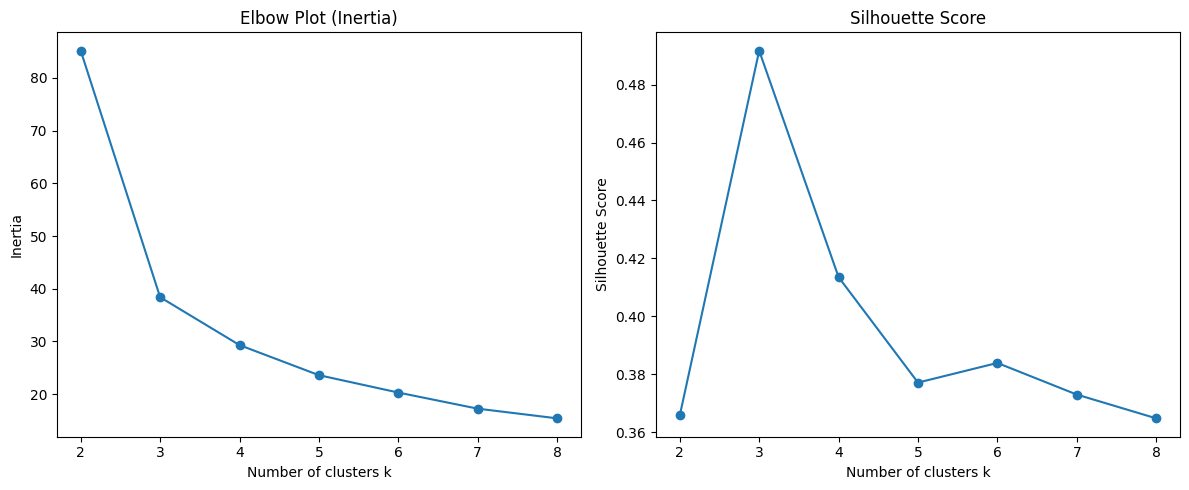

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

ks = range(2, 9)
inertia = []
silhouette = []

for k in ks:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

# Plot dei risultati
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(ks, inertia, marker='o')
axes[0].set_title("Elbow Plot (Inertia)")
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Inertia")

axes[1].plot(ks, silhouette, marker='o')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()


In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import pandas as pd
import numpy as np

# KMeans clustering con k=4
k = 4
model = KMeans(n_clusters=k, random_state=42)
nil_valid["cluster"] = model.fit_predict(X_scaled)

# Calcola silhouette per ogni NIL
nil_valid["silhouette"] = silhouette_samples(X_scaled, nil_valid["cluster"])

# Centroidi nello spazio standardizzato (GAI_z, GER_z)
centroidi = pd.DataFrame(model.cluster_centers_, columns=["GAI_z", "sqrt_pop_z"])

# Aggiungi colonne z-score al DataFrame (per calcolo distanza)
nil_valid_z = nil_valid.copy()
nil_valid_z[["GAI_z", "sqrt_pop_z"]] = X_scaled  # Assumiamo che X_scaled abbia esattamente queste due colonne

# Funzione per trovare il cluster alternativo più vicino
def trova_cluster_alternativo(row):
    assigned = row["cluster"]
    punto = np.array([row["GAI_z"], row["sqrt_pop_z"]])
    distanze = {
        label: np.linalg.norm(punto - centroide.values)
        for label, centroide in centroidi.iterrows()
        if label != assigned
    }
    return min(distanze, key=distanze.get)

# Inizializza colonna
nil_valid_z["nearest_other_cluster"] = np.nan

# Applica solo ai NIL ambigui (silhouette < 0.2)
mask_ambigui = nil_valid_z["silhouette"] < 0.2
nil_valid_z.loc[mask_ambigui, "nearest_other_cluster"] = (
    nil_valid_z[mask_ambigui].apply(trova_cluster_alternativo, axis=1)
)

# Esplora i casi ambigui (opzionale)
ambigui = nil_valid_z[mask_ambigui][
    ["NIL", "cluster", "nearest_other_cluster", "silhouette"]
].sort_values("silhouette")

display(ambigui)


,NIL,cluster,nearest_other_cluster,silhouette
81,SARPI,1,3.0,0.035432
64,DERGANO,1,3.0,0.070226
59,STADERA - CHIESA ROSSA - Q.RE TORRETTA - CONCA...,2,3.0,0.105111
49,PADOVA - TURRO - CRESCENZAGO,3,1.0,0.123165
12,DUOMO,3,0.0,0.144993
65,BAGGIO - Q.RE DEGLI OLMI - Q.RE VALSESIA,2,3.0,0.149235
85,ROGOREDO - SANTA GIULIA,0,3.0,0.154186
83,PAGANO,2,3.0,0.158871
29,GORLA - PRECOTTO,0,3.0,0.181485


In [12]:
# Solo righe con nearest_other_cluster valido
df = nil_valid_z[pd.notna(nil_valid_z["nearest_other_cluster"])][["cluster", "nearest_other_cluster"]].copy()

# Assicura interi
df["cluster"] = df["cluster"].astype(int)
df["nearest_other_cluster"] = df["nearest_other_cluster"].astype(int)

# Crea combinazione simmetrica ordinata
df["pair"] = df.apply(lambda row: tuple(sorted([row["cluster"], row["nearest_other_cluster"]])), axis=1)

# Conta le combinazioni
pair_counts = df["pair"].value_counts().reset_index()
pair_counts.columns = ["cluster_pair", "count"]

# Mostra risultato
pair_counts


,cluster_pair,count
0,"(0, 3)",3
1,"(1, 3)",3
2,"(2, 3)",3


In [7]:


# Statistiche di riepilogo per ogni cluster
cluster_summary = (
    nil_valid.groupby("cluster")
    .agg(
        mean_GAI_m2=("GAI_m2", "mean"),
        mean_sqrt_pop=("sqrt_pop", "mean"),
        mean_GER=("GER", "mean"),
        n_NILs=("cluster", "count"),
        silhouette_avg=("silhouette", "mean")
    )
    .round(2)
)

# Mostra la tabella
import pandas as pd
from IPython.display import display
display(cluster_summary)


,mean_GAI_m2,mean_sqrt_pop,mean_GER,n_NILs,silhouette_avg
cluster,,,,,
0,380.01,19.03,24.92,20,0.44
1,422.74,32.76,14.35,16,0.43
2,623.46,22.11,34.86,15,0.43
3,487.27,26.30,21.98,16,0.34


In [8]:
# Calcola lo Z-score sulle 3 variabili usate
scaler = StandardScaler()
Z = scaler.fit_transform(nil_valid_z[["GAI_m2", "sqrt_pop", "GER"]])
nil_valid_z[["GAI_z", "sqrt_pop_z", "GER_z"]] = Z

# Media z-score per cluster + numero di NIL + silhouette medio
cluster_z_summary = (
    nil_valid_z.groupby("cluster")
    .agg(
        GAI_z=("GAI_z", "mean"),
        sqrt_pop_z=("sqrt_pop_z", "mean"),
        GER_z=("GER_z", "mean"),
        n_NILs=("cluster", "count"),
        silhouette_avg=("silhouette", "mean")
    )
    .round(2)
)

display(cluster_z_summary)


,GAI_z,sqrt_pop_z,GER_z,n_NILs,silhouette_avg
cluster,,,,,
0,-0.87,-0.98,0.11,20,0.44
1,-0.46,1.37,-1.06,16,0.43
2,1.47,-0.45,1.21,15,0.43
3,0.16,0.27,-0.21,16,0.34


In [9]:
from sklearn.metrics import silhouette_score

# Silhouette medio complessivo
global_silhouette = silhouette_score(X_scaled, nil_valid["cluster"])
print(f"Global silhouette score (k=3): {global_silhouette:.3f}")


Global silhouette score (k=3): 0.414


In [10]:
# Conteggio NIL ambigui per cluster
ambigui_per_cluster = (
    nil_valid_z[nil_valid_z["silhouette"] < 0.2]
    .groupby("cluster")
    .size()
    .rename("n_ambigui")
)

display(ambigui_per_cluster)


,n_ambigui
cluster,
0,2
1,2
2,3
3,2


In [11]:
import folium
import pandas as pd
from branca.colormap import linear

# Palette coerente con i profili urbani (K=4)
cluster_colors = {
    0: "#c29c59",  # ocra/marrone – marginali
    1: "#e34a33",  # rosso – critici
    2: "#31a354",  # verde – privilegiati
    3: "#ffcc00",  # giallo – intermedi
}

legend_html = """
<div style="
    position: fixed;
    bottom: 30px; left: 30px; width: 160px;
    background-color: white;
    border: 2px solid #ccc;
    z-index: 9999;
    font-size: 13px;
    padding: 10px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
    line-height: 1.5;
">
    <b>Cluster ID</b><br><br>
    <i style="background: #c29c59; width: 14px; height: 14px; float: left; margin-right: 8px;"></i> Cluster 0<br>
    <i style="background: #e34a33; width: 14px; height: 14px; float: left; margin-right: 8px;"></i> Cluster 1<br>
    <i style="background: #31a354; width: 14px; height: 14px; float: left; margin-right: 8px;"></i> Cluster 2<br>
    <i style="background: #ffcc00; width: 14px; height: 14px; float: left; margin-right: 8px;"></i> Cluster 3<br>
    <i style="background: #999999; width: 14px; height: 14px; float: left; margin-right: 8px;"></i> Not in analysis
</div>
"""


# Copia di tutti i NIL
nil_map = nil_gdf.copy()

# Etichetta NIL inclusi nell'analisi
nil_map["in_analysis"] = nil_map.index.isin(nil_valid_z.index)

# Colonne da unire da nil_valid_z
cluster_data = nil_valid_z[[
    "cluster", "GAI_z", "GER_z", "sqrt_pop_z", "silhouette", "nearest_other_cluster"
]].copy()
nil_map = nil_map.join(cluster_data, how="left")

# Etichetta cluster principale
nil_map["cluster_label"] = nil_map["cluster"].fillna(-1).astype(int)

# Inizializza la mappa
m = folium.Map(location=[45.4642, 9.19], zoom_start=11, tiles="cartodbpositron")

# Ciclo su ogni NIL
for _, row in nil_map.iterrows():
    cid = row["cluster_label"]
    fill_color = cluster_colors.get(cid, "#999999")  # NIL esclusi = grigio chiaro
    alt_cluster = int(row["nearest_other_cluster"]) if pd.notna(row.get("nearest_other_cluster")) else None

    # Colore bordo per NIL ambigui
    if row["in_analysis"] and row["silhouette"] < 0.2 and alt_cluster in cluster_colors:
        border_color = cluster_colors[alt_cluster]
        border_weight = 2.5
    else:
        border_color = "black"
        border_weight = 0.5

    # Tooltip informativo
    if row["in_analysis"]:
        tooltip_vars = [
            f"NIL: {row['NIL']}",
            f"Cluster: {cid}",
            f"Alt. Cluster: {alt_cluster if alt_cluster is not None else '–'}",
            f"GAI_z: {row['GAI_z']:.2f}",
            f"GER_z: {row['GER_z']:.2f}",
            f"sqrt_pop_z: {row['sqrt_pop_z']:.2f}",
            f"Silhouette: {row['silhouette']:.2f}"
        ]
    else:
        tooltip_vars = [f"NIL: {row['NIL']}", "Not included in analysis"]

    tooltip = folium.Tooltip("<br>".join(tooltip_vars))

    # Aggiunta del poligono NIL
    folium.GeoJson(
        row["geometry"],
        style_function=lambda x, col=fill_color, bcol=border_color, bw=border_weight: {
            "fillColor": col,
            "color": bcol,
            "weight": bw,
            "fillOpacity": 0.6,
        },
        tooltip=tooltip
    ).add_to(m)

m.get_root().html.add_child(folium.Element(legend_html))

# Mostra mappa
m
